In [69]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [70]:
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')
df_store = pd.read_csv('../data/store.csv')

/tmp/ipykernel_34460/267565919.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('../data/train.csv')


In [71]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [72]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek      41088 non-null  int64  
 3   Date           41088 non-null  str    
 4   Open           41077 non-null  float64
 5   Promo          41088 non-null  int64  
 6   StateHoliday   41088 non-null  str    
 7   SchoolHoliday  41088 non-null  int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 2.5 MB


In [73]:
df_store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [74]:
print(df_train.shape)
print(df_test.shape)
print(df_store.shape)

(1017209, 9)
(41088, 8)
(1115, 10)


In [75]:
def merge_store(df_store : pd.DataFrame, df_train : pd.DataFrame) -> pd.DataFrame:
    df_store_copy = df_store.copy()
    df_train_copy = df_train.copy()
    df_train_copy['Date'] = pd.to_datetime(df_train_copy['Date'])
    df_full = pd.merge(df_store_copy, df_train_copy, on='Store', how='left')
    return df_full 

df_train_full = merge_store(df_store, df_train)

In [76]:
df_train_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   StoreType                  1017209 non-null  str           
 2   Assortment                 1017209 non-null  str           
 3   CompetitionDistance        1014567 non-null  float64       
 4   CompetitionOpenSinceMonth  693861 non-null   float64       
 5   CompetitionOpenSinceYear   693861 non-null   float64       
 6   Promo2                     1017209 non-null  int64         
 7   Promo2SinceWeek            509178 non-null   float64       
 8   Promo2SinceYear            509178 non-null   float64       
 9   PromoInterval              509178 non-null   str           
 10  DayOfWeek                  1017209 non-null  int64         
 11  Date                       1017209 non-null  dat

<Axes: >

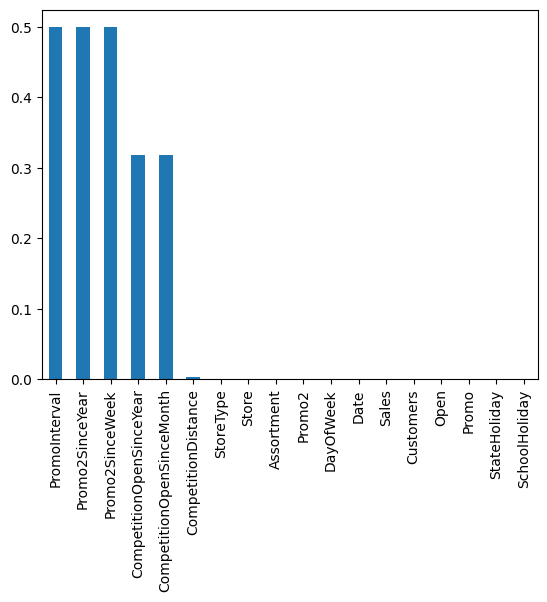

In [77]:
df_train_full.isna().mean().sort_values(ascending=False).plot(kind='bar')

In [78]:
print(df_train_full['Date'].min())
print(df_train_full['Date'].max())

2013-01-01 00:00:00
2015-07-31 00:00:00


In [79]:
print(df_train_full['Store'].nunique())

1115


In [80]:
print(df_train_full['DayOfWeek'].nunique())

7


In [81]:
def count_sales_per_date(df):
    df_copy = df.copy()
    result = df_copy.groupby('Date')['Sales'].count().reset_index()
    return result 

res = count_sales_per_date(df_train_full)

print(res.sort_values(by=['Sales'], ascending=False))
print(res['Sales'].min())
print(res['Sales'].max())

          Date  Sales
941 2015-07-31   1115
940 2015-07-30   1115
1   2013-01-02   1115
2   2013-01-03   1115
3   2013-01-04   1115
..         ...    ...
551 2014-07-06    935
553 2014-07-08    935
554 2014-07-09    935
555 2014-07-10    935
556 2014-07-11    935

[942 rows x 2 columns]
935
1115


In [82]:
def basic_stats(df):
    df_copy = df.copy()
    df1 = df_copy[df_copy['Open'] == 0]
    records_open_zero = len(df1) 
    records_sales_zero = len(df1[df1['Sales'] == 0])
    records_open_zero_sales = len(df1[df1['Sales'] > 0])
    return records_open_zero, records_sales_zero, records_open_zero_sales

print(basic_stats(df_train_full))

(172817, 172817, 0)


In [83]:
def open_equal_zero(df):
    return f'Udzial sklepów z Open=0: {round(len(df[df['Open'] == 0]) / len(df) * 100, 2)}%'

print(open_equal_zero(df_train_full))

Udzial sklepów z Open=0: 16.99%


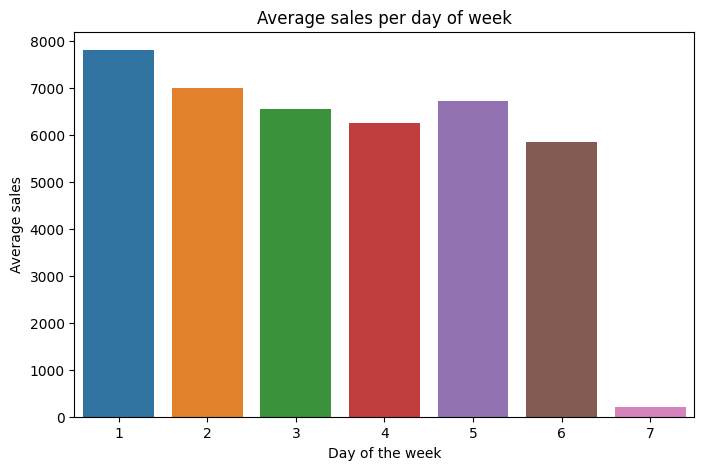

In [84]:
data = df_train_full.groupby('DayOfWeek')['Sales'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=data, 
    x='DayOfWeek', 
    y='Sales', 
    hue='DayOfWeek', 
    palette='tab10',
    legend=False
)
plt.title('Average sales per day of week')
plt.xlabel('Day of the week')
plt.ylabel('Average sales')
plt.xticks(rotation=0)
plt.show()

In [85]:
df_with_promo = df_train_full[df_train_full['Promo'] == 0]
df_without_promo = df_train_full[df_train_full['Promo'] == 1]

print(f'Average sales without promo: {df_without_promo['Sales'].mean()}')
print(f'Average sales with promo: {df_with_promo['Sales'].mean()}')
print(f'Median sales without promo: {df_without_promo['Sales'].median()}')
print(f'Median sales with promo: {df_with_promo['Sales'].median()}')



Average sales without promo: 7991.152045969903
Average sales with promo: 4406.050805160786
Median sales without promo: 7553.0
Median sales with promo: 4622.0


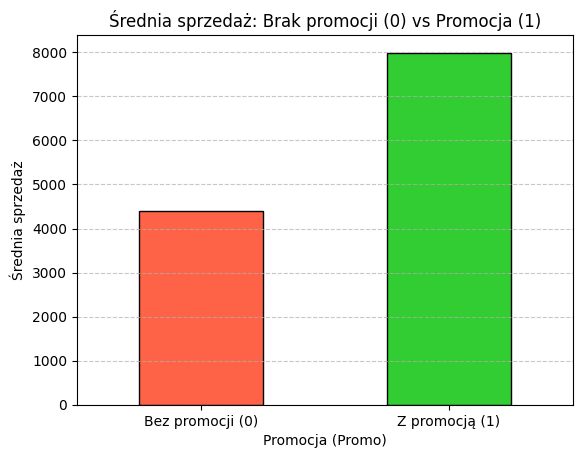

In [86]:
promo_stats = df_train_full.groupby('Promo')['Sales'].agg(['mean', 'median', 'count'])

promo_stats['mean'].plot(kind='bar', color=['tomato', 'limegreen'], edgecolor='black')
plt.title('Średnia sprzedaż: Brak promocji (0) vs Promocja (1)')
plt.xlabel('Promocja (Promo)')
plt.ylabel('Średnia sprzedaż')
plt.xticks(ticks=[0, 1], labels=['Bez promocji (0)', 'Z promocją (1)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

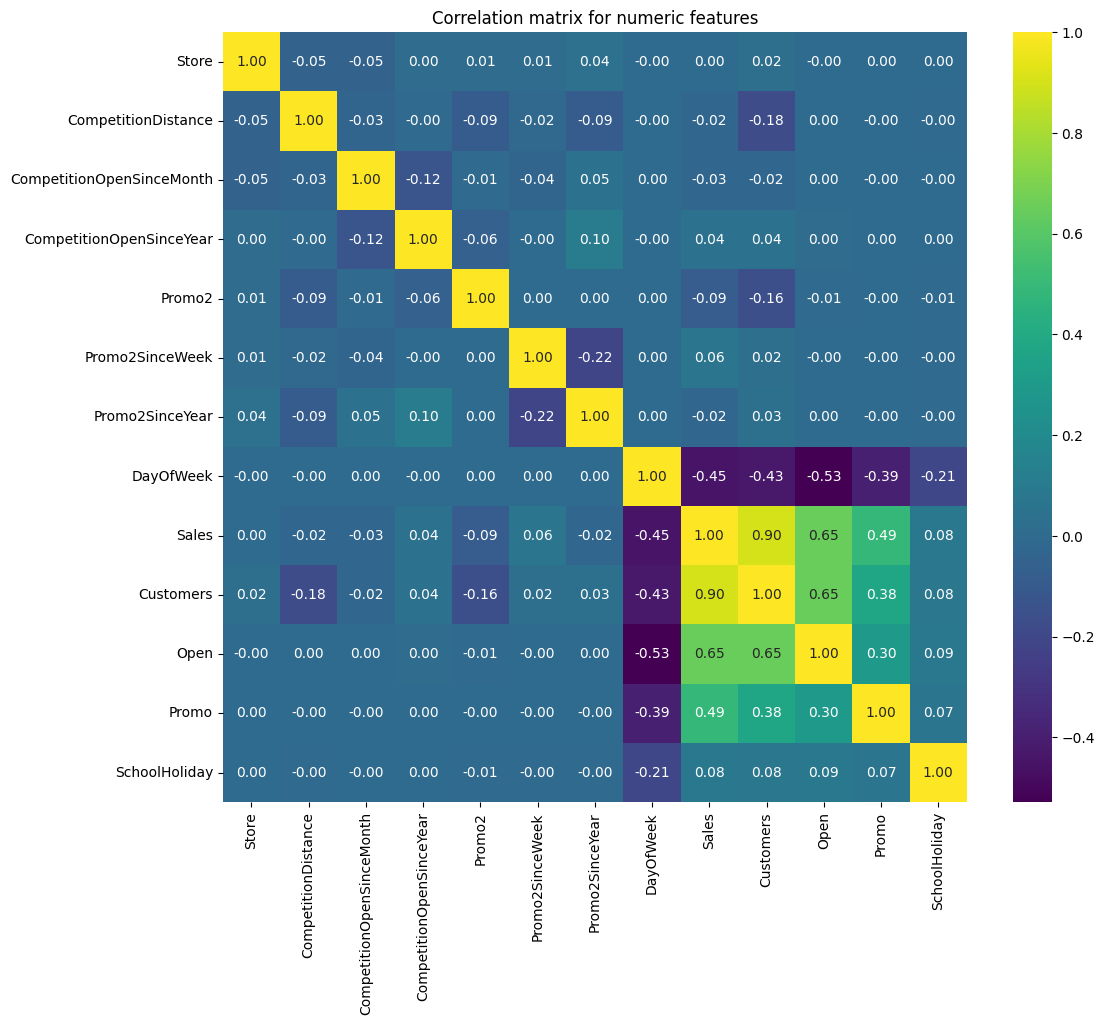

In [87]:
df_full_numeric = df_train_full.select_dtypes(include=['number'])
corr_matrix = df_full_numeric.corr('spearman').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='viridis')
plt.title('Correlation matrix for numeric features')
plt.show()


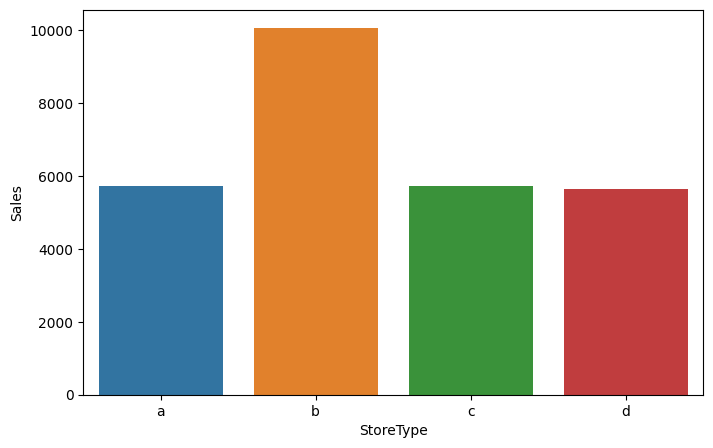

In [88]:
data = df_train_full.groupby('StoreType')['Sales'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(
    data = data, 
    x='StoreType', 
    y='Sales', 
    hue='StoreType',
    palette='tab10', 
    legend=False
)
plt.show()

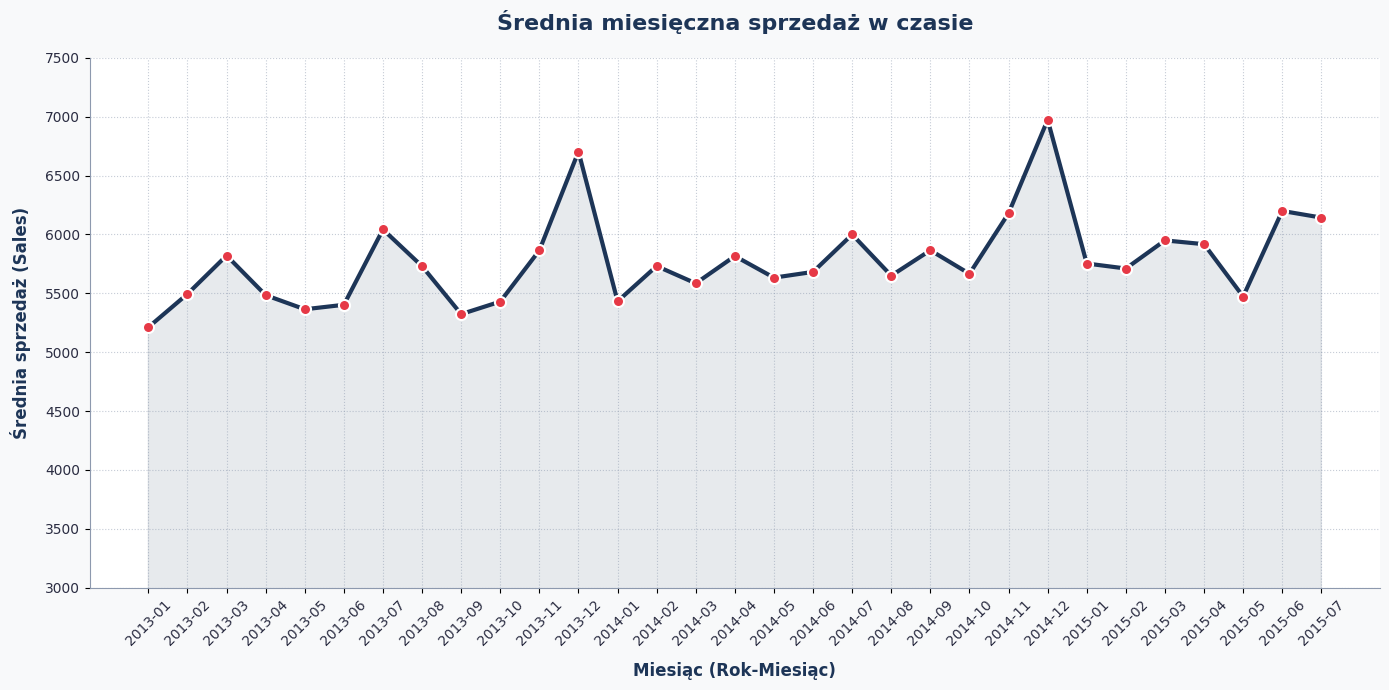

In [89]:
df_train_full['YearMonth'] = df_train_full['Date'].dt.to_period('M')
monthly_sales = df_train_full.groupby('YearMonth')['Sales'].mean()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14, 7), facecolor='#f8f9fa')
ax = plt.axes()
ax.set_facecolor('#ffffff')

line_color = '#1d3557'

plt.plot(
    monthly_sales.index, 
    monthly_sales.values, 
    color=line_color, 
    linewidth=3, 
    marker='o', 
    markersize=8, 
    markerfacecolor='#e63946', 
    markeredgecolor='#ffffff', 
    markeredgewidth=1.5,
    label='Średnia sprzedaż'
)

plt.fill_between(
    monthly_sales.index, 
    monthly_sales.values, 
    color=line_color, 
    alpha=0.1
)

plt.xticks(range(len(monthly_sales)), monthly_sales.index, rotation=45, fontsize=10, color='#2b2d42')
plt.yticks(fontsize=10, color='#2b2d42')

plt.title('Średnia miesięczna sprzedaż w czasie', fontsize=16, fontweight='bold', pad=20, color='#1d3557')
plt.xlabel('Miesiąc (Rok-Miesiąc)', fontsize=12, fontweight='semibold', labelpad=10, color='#1d3557')
plt.ylabel('Średnia sprzedaż (Sales)', fontsize=12, fontweight='semibold', labelpad=10, color='#1d3557')
plt.ylim(3000, 7500)
plt.grid(True, linestyle=':', alpha=0.5, color='#8d99ae')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#8d99ae')
ax.spines['bottom'].set_color('#8d99ae')

plt.tight_layout()
plt.show()